<a href="https://colab.research.google.com/github/ADESHcfd/ODE_PDE-using-ANN/blob/main/ode_trd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 2
Solving Ordinary Differential Equations Using Traditional Numerical Methods

An ODE relates a function with its derivatives:

dy/dx = f(x, y)

In many real-world problems, analytical solutions are difficult or impossible to obtain. Therefore, numerical methods are used to approximate the solution.

In this chapter, we demonstrate classical numerical approaches:
- Euler Method
- Improved Euler (Heun Method)
- Runge–Kutta Method (RK4)
- Using numerical libraries such as SciPy

These approaches will later serve as baseline methods for comparison with Artificial Neural Networks.








Problem Definition

Consider the first-order ODE:

dy/dx = -2y

with the initial condition:



Consider the ordinary differential equation

dy/dx = -2y ,  y(0) = 1

This equation can be solved analytically using the method of separation of variables.

Step 1: Separate the variables

dy/dx = -2y

(1/y) dy = -2 dx

Step 2: Integrate both sides

∫(1/y) dy = ∫(-2) dx

ln|y| = -2x + C

Step 3: Solve for y

y = Ce^(-2x)

Step 4: Apply the initial condition y(0) = 1

1 = Ce^0  
C = 1

Final analytical solution:

y(x) = e^(-2x)

This exact solution is used as a reference to evaluate the accuracy of numerical methods such as Euler and Runge–Kutta.

In [1]:
#Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Define the Differential Equation

def f(x, y):
    return -2*y

In [8]:
#Exact Solution (For Comparison)

def exact_solution(x):
    return np.exp(-2*x)


In [11]:

x_exact = np.linspace(0, 5, 100)
y_exact = exact_solution(x_exact)

Euler Method

Theory:

The Euler Method is the simplest numerical technique for solving ODEs.


Formula:

y(n+1) = y(n) + h f(x(n), y(n))

Where:

h  = step size

x(n) = current point

y(n) = current approximation

The method uses the tangent slope to estimate the next value.

In [26]:
def euler_method(f, x0, y0, h, n):

    x = [x0]
    y = [y0]

    for i in range(n):

        y_new = y[-1] + h * f(x[-1], y[-1])
        x_new = x[-1] + h

        x.append(x_new)
        y.append(y_new)

    return np.array(x), np.array(y)





# explaination

f → the function representing the ODE: dy/dx = f(x, y)




dx
dy​
=f(x,y)

x0 → the initial value of
𝑥
x (starting point)

y0 → the initial value of
𝑦
y (solution at
𝑥
0
x0)

h → step size (distance between consecutive
𝑥
x points)

n → number of steps to take

This sets up the Euler numerical solver.



Initialize Lists to Store Values

x → list to store x-values (starting with x0)

y → list to store y-values (starting with y0)


y_new = y[-1] + h * f(x[-1], y[-1])

x_new = x[-1] + h

which is

y[-1] → current value of
𝑦

x[-x] → current value of x

f(x[-1], y[-1]) → slope at current point (from the ODE)

h * f(x[-1], y[-1]) → approximate change in y over one step

y_new → next value of y

​x_new → next value of x (just add the step size h)


x.append(x_new)
y.append(y_new)

Add the new point to the lists

This way, the next iteration will use the new current values


#Euler Method Step-by-Step Explanation

Consider the ODE:

dy/dx = -2y , y(0) = 1

Step size h = 0.1

The Euler update formula is:

y_new = y_current + h * f(x_current, y_current)

x_new = x_current + h

-------------------------------------------
Step 0: Initialization

x0 = 0, y0 =

Lists: x = [0], y = [1]

-------------------------------------------
Step 1 (i = 0):

Slope: f(x0, y0) = -2*1 = -2

y1 = 1 + 0.1*(-2) = 0.8

x1 = 0 + 0.1 = 0.1

Lists: x = [0, 0.1], y = [1, 0.8]

-------------------------------------------
Step 2 (i = 1):

Slope: f(x1, y1) = -2*0.8 = -1.6

y2 = 0.8 + 0.1*(-1.6) = 0.64

x2 = 0.1 + 0.1 = 0.2

Lists: x = [0, 0.1, 0.2], y = [1, 0.8, 0.64]

-------------------------------------------
Step 3 (i = 2):

Slope: f(x2, y2) = -2*0.64 = -1.28

y3 = 0.64 + 0.1*(-1.28) = 0.512

x3 = 0.2 + 0.1 = 0.3

Lists: x = [0, 0.1, 0.2, 0.3], y = [1, 0.8, 0.64, 0.512]

-------------------------------------------



Runge–Kutta Method (RK4)

Theory:

The Runge–Kutta 4th order method (RK4) is a numerical method for solving ordinary differential equations (ODEs).
It is much more accurate than the Euler method because it evaluates the slope at multiple points within each step.

The method computes four slopes:

k1 = f(x_n, y_n)

k2 = f(x_n + h/2, y_n + h*k1/2)

k3 = f(x_n + h/2, y_n + h*k2/2)

k4 = f(x_n + h,   y_n + h*k3)


- k1: slope at the beginning of the interval
- k2: slope at the midpoint using k1
- k3: slope at the midpoint using k2
- k4: slope at the end of the interval using k3

Update Rule:

y_{n+1} = y_n + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

x_{n+1} = x_n + h

Explanation:

1. Start with the current point (x_n, y_n).
2. Compute k1 using the current slope.
3. Compute k2 using the slope at the midpoint (x_n + h/2) and y_n adjusted by k1.
4. Compute k3 using the slope at the midpoint and y_n adjusted by k2.
5. Compute k4 using the slope at the end of the interval and y_n adjusted by k3.
6. Combine the four slopes in a weighted average to get y_{n+1}.
7. Increment x by the step size h.
8. Repeat for the desired number of steps.

Advantages:

- Much higher accuracy than Euler for the same step size.
- Captures the curvature of the solution by averaging slopes.
- Widely used in scientific computing and engineering problems.





#Runge–Kutta 4th Order (RK4) Method Step-by-Step Example

ODE: dy/dx = -2y , y(0) = 1

Step size h = 0.1

RK4 formulas:.

k1 = f(x_n, y_n)

k2 = f(x_n + h/2, y_n + h*k1/2)

k3 = f(x_n + h/2, y_n + h*k2/2)

k4 = f(x_n + h, y_n + h*k3)

y_{n+1} = y_n + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

x_{n+1} = x_n + h

-------------------------------------------
Step 0: Initialization
x0 = 0, y0 = 1

-------------------------------------------
Step 1 (n = 0):

k1 = f(0,1) = -2*1 = -2

k2 = f(0.05, 1 + 0.05*(-2)) = f(0.05, 0.9) = -2*0.9 = -1.8

k3 = f(0.05, 1 + 0.05*(-1.8)) = f(0.05, 0.91) = -2*0.91 = -1.82

k4 = f(0.1, 1 + 0.1*(-1.82)) = f(0.1, 0.818) = -2*0.818 = -1.636

y1 = 1 + (0.1/6)*(-2 + 2*(-1.8) + 2*(-1.82) + (-1.636)) ≈ 0.7891

x1 = 0.1

-------------------------------------------
Step 2 (n = 1):

k1 = f(0.1, 0.7891) = -2*0.7891 = -1.5782

k2 = f(0.15, 0.7891 + 0.05*(-1.5782)) = f(0.15, 0.7102) = -2*0.7102 = -1.4204

k3 = f(0.15, 0.7891 + 0.05*(-1.4204)) = f(0.15, 0.7181) = -2*0.7181 = -1.4362

k4 = f(0.2, 0.7891 + 0.1*(-1.4362)) = f(0.2, 0.6455) = -2*0.6455 = -1.2910

y2 = 0.7891 + (0.1/6)*(-1.5782 + 2*(-1.4204) + 2*(-1.4362) + (-1.2910)) ≈ 0.6293

x2 = 0.2



In [28]:
#  Runge-Kutta 4th Order Method


def rk4_method(f, x0, y0, h, n):

    x = [x0]
    y = [y0]

    for i in range(n):

        k1 = f(x[-1], y[-1])
        k2 = f(x[-1] + h/2, y[-1] + h*k1/2)
        k3 = f(x[-1] + h/2, y[-1] + h*k2/2)
        k4 = f(x[-1] + h, y[-1] + h*k3)

        y_new = y[-1] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x_new = x[-1] + h

        x.append(x_new)
        y.append(y_new)

    return np.array(x), np.arr

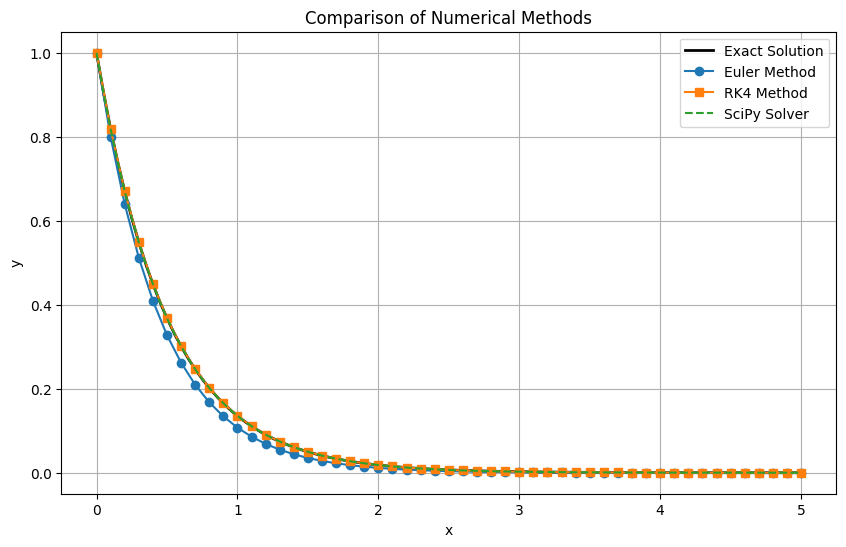

Maximum Errors:
Euler Method Max Error: 0.04019944117144231
RK4 Method Max Error: 5.79695385960477e-06
SciPy Solver Max Error: 0.00041459537600385676


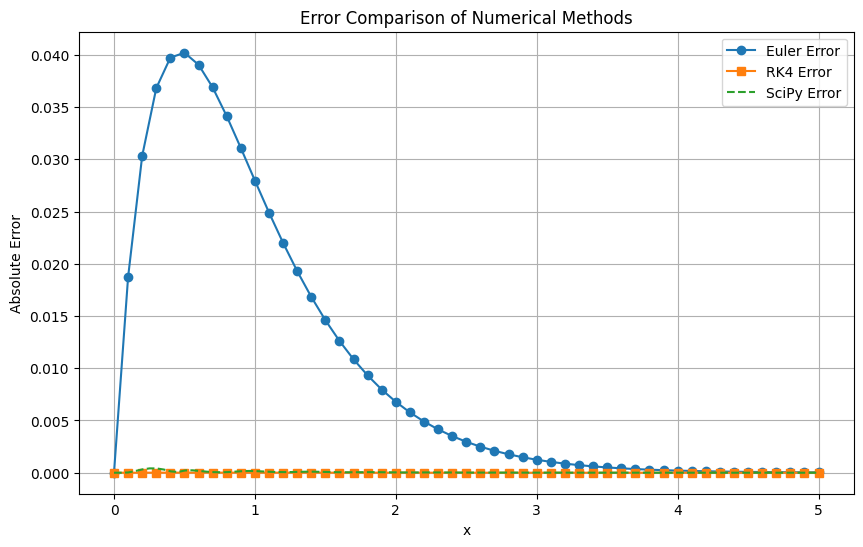

In [29]:
#full code
# Chapter 2: Solving ODEs with Traditional Numerical Methods

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -------------------------------
# 1. Define the differential equation
# -------------------------------
def f(x, y):
    return -2*y

# -------------------------------
# 2. Exact solution (for comparison)
# -------------------------------
def exact_solution(x):
    return np.exp(-2*x)

# -------------------------------
# 3. Euler Method
# -------------------------------
def euler_method(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        y_new = y[-1] + h * f(x[-1], y[-1])
        x_new = x[-1] + h
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# -------------------------------
# 4. Runge-Kutta 4th Order Method (RK4)
# -------------------------------
def rk4_method(f, x0, y0, h, n):
    x = [x0]
    y = [y0]
    for i in range(n):
        k1 = f(x[-1], y[-1])
        k2 = f(x[-1] + h/2, y[-1] + h*k1/2)
        k3 = f(x[-1] + h/2, y[-1] + h*k2/2)
        k4 = f(x[-1] + h, y[-1] + h*k3)
        y_new = y[-1] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x_new = x[-1] + h
        x.append(x_new)
        y.append(y_new)
    return np.array(x), np.array(y)

# -------------------------------
# 5. Parameters
# -------------------------------
x0 = 0
y0 = 1
h = 0.1
n = 50

# -------------------------------
# 6. Solve using Euler and RK4
# -------------------------------
x_euler, y_euler = euler_method(f, x0, y0, h, n)
x_rk4, y_rk4 = rk4_method(f, x0, y0, h, n)

# -------------------------------
# 7. Solve using SciPy solver
# -------------------------------
solution = solve_ivp(
    f,
    [0, 5],
    [1],
    t_eval=np.linspace(0, 5, 100)
)
x_scipy = solution.t
y_scipy = solution.y[0]

# -------------------------------
# 8. Exact solution for comparison
# -------------------------------
x_exact = np.linspace(0, 5, 100)
y_exact = exact_solution(x_exact)

# -------------------------------
# 9. Visualization
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(x_exact, y_exact, 'k', linewidth=2, label="Exact Solution")
plt.plot(x_euler, y_euler, 'o-', label="Euler Method")
plt.plot(x_rk4, y_rk4, 's-', label="RK4 Method")
plt.plot(x_scipy, y_scipy, '--', label="SciPy Solver")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Numerical Methods")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------------
# 10. Error Analysis
# -------------------------------
error_euler = np.abs(exact_solution(x_euler) - y_euler)
error_rk4 = np.abs(exact_solution(x_rk4) - y_rk4)
error_scipy = np.abs(exact_solution(x_scipy) - y_scipy)

print("Maximum Errors:")
print("Euler Method Max Error:", np.max(error_euler))
print("RK4 Method Max Error:", np.max(error_rk4))
print("SciPy Solver Max Error:", np.max(error_scipy))

# Optional: Plot the errors
plt.figure(figsize=(10,6))
plt.plot(x_euler, error_euler, 'o-', label="Euler Error")
plt.plot(x_rk4, error_rk4, 's-', label="RK4 Error")
plt.plot(x_scipy, error_scipy, '--', label="SciPy Error")
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.title("Error Comparison of Numerical Methods")
plt.grid(True)
plt.legend()
plt.show()